Goal: Build a small-scale cosmological simulation that generates overdensities and filamentary structure

Steps:
1. initialize particles on grid
2. apply Zel'dovich displacements
3. main loop
* CIC interpolation
* FFT to solve the Poisson equation (particle mesh, Barnes-Hut for speed & scaling later)
* Leapfrog integration to get the next step
* Periodic boundary conditions and Universe expansion factored in later (??)

In [1]:
## packages

import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import os
import time
from mpl_toolkits.mplot3d import Axes3D

In [15]:
n = 64
box_size = 1.0

G = 3.0          # stronger gravity (important)
dt = 0.001        # should be on the same order as the dynamical time
nsteps = 100     # enough for evolution but not too slow

sigma = 0.5     # stronger initial perturbations
D = 0.65          # Zel’dovich displacement amplitude

growth_rate = 1.0

power_index = -2.0
epsilon = 0.01

STEP 1: PARTICLE INITIALIZATION ON GRID

(1000, 3)


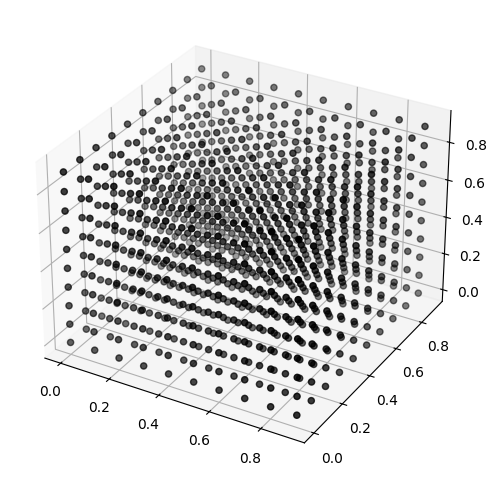

In [16]:
## creates a uniform 3D grid of particles, returning their positions as a (N, 3) array

def initialize_grid(n, box_size):
    
    coords = np.linspace(0, box_size, n, endpoint = False)
    X, Y, Z = np.meshgrid(coords, coords, coords, indexing = "ij")
    pos = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T
    
    return pos

## visualization of particle initialization:

particle_locations = initialize_grid(10, 1.0)
print(particle_locations.shape)     ## shape should be (n^3, 3)

fig = plt.figure(figsize = (6, 6))
ax = fig.add_subplot(projection = '3d')

x = particle_locations[:, 0]
y = particle_locations[:, 1]
z = particle_locations[:, 2]

ax.scatter(x, y, z, color = "black")
plt.show()

In [17]:
## now that we have a function to initialize particles, we want to make those particle locations physically relevant
## we can do this by sampling from a density field

## generate a Gaussian random field using a toy power spectrum in Fourier space

def generate_gaussian_field(n, box_size, power_index = power_index, epsilon = epsilon):

    kfreq = np.fft.fftfreq(n, d = box_size / n) * (2 * np.pi)
    kx, ky, kz = np.meshgrid(kfreq, kfreq, kfreq, indexing = "ij")
    k = np.sqrt(kx**2 + ky**2 + kz**2)

    ## avoid division by zero:
    k[0, 0, 0] = 1.0

    ## toy power spectrum --> P(k) ~ k^-2
    Pk = (k + epsilon) ** power_index

    ## adding Gaussian noise
    noise = np.random.normal(size = (n, n, n)) + 1j * np.random.normal(size = (n, n, n))

    delta_k = noise * np.sqrt(Pk)
    delta_k[0, 0, 0] = 0.0       ## zero mean density

    delta = np.fft.ifftn(delta_k).real    ## inverse Fourier transform to get back to position-space

    return delta

## normalizing delta to a specific RMS amplitude, fixes small value problems

def normalize_density(delta, sigma = 0.1):
    
    delta = delta - np.mean(delta)
    delta /= np.std(delta)
    delta *= sigma
    
    return delta


#############################################################################

## visualization 1: slice of 3D density field

def plot_density_slice(delta, axis = 2, index = None):
    
    n = delta.shape[0]
    
    if index is None:
        index = n // 2  # middle slice

    if axis == 0:
        slice_2d = delta[index, :, :]
    elif axis == 1:
        slice_2d = delta[:, index, :]
    else:
        slice_2d = delta[:, :, index]

    plt.figure(figsize = (6, 6))
    plt.imshow(slice_2d, origin = 'lower', cmap = 'RdBu')
    plt.title("Visualization 1: Slice of 3D Density Field")
    plt.colorbar(label = 'Density contrast δ')
    plt.show()

#############################################################################

## visualization 2: PDF of density field (should be Gaussian)

def plot_density_histogram(delta):
    
    plt.hist(delta.flatten(), bins = 100, density = True)
    plt.title("Visualization 2: Density Field Distribution")
    plt.xlabel("δ")
    plt.ylabel("PDF")
    plt.show()

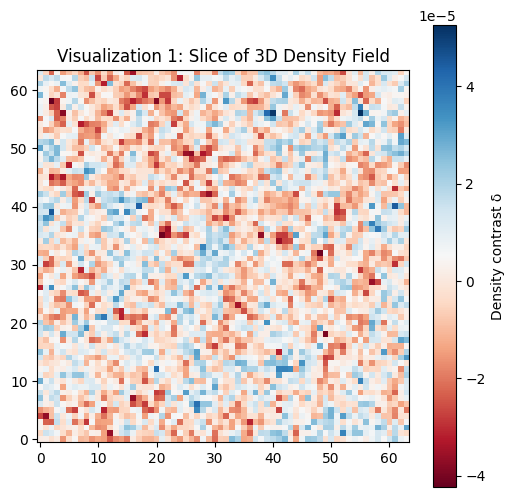

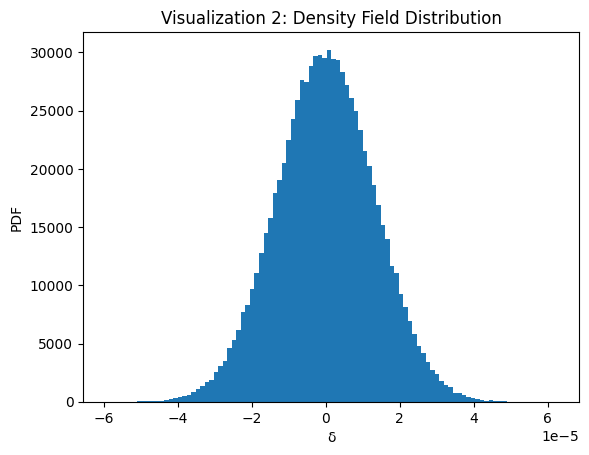

In [18]:
test = generate_gaussian_field(n = n, box_size = box_size)

plot_density_slice(test)
plot_density_histogram(test)

STEP 2: Apply Zel'dovich Displacements

In [19]:
## next step: create a set of functions that applies Zel'dovich displacements x(t) = q + b(t)*f(q)
## we can again start in Fourier space, then transform back to position space
## q = Lagrangian (initial) coordinate
## b(t) = time-scaling factor
## f(q) is the displacement field

def compute_displacement_field(delta, box_size):

    n = delta.shape[0]

    kfreq = np.fft.fftfreq(n, d = box_size / n) * (2 * np.pi)
    kx, ky, kz = np.meshgrid(kfreq, kfreq, kfreq, indexing = "ij")
    
    k2 = (kx**2 + ky**2 + kz**2)
    k2[0, 0, 0] = 1.0

    delta_k = np.fft.fftn(delta)

    factor = 1j / k2

    sx_k = factor * kx * delta_k
    sy_k = factor * ky * delta_k
    sz_k = factor * kz * delta_k

    sx = np.fft.ifftn(sx_k).real
    sy = np.fft.ifftn(sy_k).real
    sz = np.fft.ifftn(sz_k).real

    return sx, sy, sz

## D = growth factor
def apply_zeldovich_displacements(positions, sx, sy, sz, box_size, D):
    
    n = sx.shape[0]
    dx = box_size / n

    ## map particle positions to grid indices
    grid_idx = (positions / dx).astype(int) % n

    disp = np.zeros_like(positions)

    disp[:, 0] = sx[grid_idx[:, 0], grid_idx[:, 1], grid_idx[:, 2]]
    disp[:, 1] = sy[grid_idx[:, 0], grid_idx[:, 1], grid_idx[:, 2]]
    disp[:, 2] = sz[grid_idx[:, 0], grid_idx[:, 1], grid_idx[:, 2]]


    pos_final = positions + D * disp
    pos_final %= box_size  # periodic boundary conditions
    
    return pos_final, disp

In [20]:
## computing initial velocity field

def compute_velocities(disp, growth_rate):

    # IMPORTANT: no extra scaling factors elsewhere
    vel = growth_rate * disp

    return vel

In [21]:
## ONE FUNCTION TO GENERATE INITIAL CONDITIONS:

In [22]:
## function to generate initial conditions:

def run_initial_conditions(n, box_size, sigma, D, growth_rate):

    # grid
    pos = initialize_grid(n, box_size)

    # density field
    delta = generate_gaussian_field(n, box_size)
    delta = normalize_density(delta, sigma = sigma)

    # displacement field
    sx, sy, sz = compute_displacement_field(delta, box_size)

    # apply displacement
    pos_final, disp = apply_zeldovich_displacements(pos, sx, sy, sz, box_size, D = D)

    # velocities (CONSISTENT, no double scaling)
    vel = compute_velocities(disp, growth_rate = growth_rate)

    return pos, pos_final, vel, delta, disp

In [23]:
pos_initial, pos_final, vel, delta, disp = run_initial_conditions(n, box_size, sigma, D, growth_rate)

In [24]:
## visualizations of initial conditions:

## initial versus dispersed particles
def plot_initial_vs_displaced(pos_initial, pos_final, box_size):
    fig, ax = plt.subplots(1, 2, figsize = (10, 5))

    ax[0].scatter(pos_initial[:,0], pos_initial[:,1], s = 1)
    ax[0].set_title("Initial Lagrangian grid")
    ax[0].set_xlim(0, box_size)
    ax[0].set_ylim(0, box_size)

    ax[1].scatter(pos_final[:,0], pos_final[:,1], s=1)
    ax[1].set_title("Zel'dovich displaced field")
    ax[1].set_xlim(0, box_size)
    ax[1].set_ylim(0, box_size)

    plt.tight_layout()
    plt.show()

## flow of particles
def plot_velocity_field(pos_initial, vel, box_size, step = 2):

    plt.figure(figsize = (6,6))

    plt.quiver(pos_initial[::step, 0], pos_initial[::step, 1], vel[::step, 0], vel[::step, 1], scale = 0.8)

    plt.title("Initial velocity field (Zel'dovich)")
    plt.xlim(0, box_size)
    plt.ylim(0, box_size)
    plt.show()

## velocity magnitude map
def plot_velocity_magnitude(vel):

    vmag = np.linalg.norm(vel, axis = 1)

    plt.figure(figsize = (5, 4))
    plt.hist(vmag, bins = 80)
    plt.title("Velocity magnitude distribution")
    plt.xlabel("|v|")
    plt.ylabel("count")
    plt.show()

    print("vmin:", vmag.min(), "vmax:", vmag.max(), "mean:", vmag.mean())

## displacement magnitude map
def plot_displacement_magnitude(disp, n, box_size):

    mag = np.linalg.norm(disp, axis = 1)
    grid = mag.reshape(n, n, n)

    slice2d = grid[:, :, n//2]

    plt.figure(figsize = (5,5))
    plt.imshow(slice2d, origin = 'lower', cmap = 'viridis')
    plt.colorbar(label = "|displacement|")
    plt.title("Displacement magnitude slice")
    plt.show()

def velocity_alignment_check(disp, vel):

    d = disp / (np.linalg.norm(disp, axis = 1, keepdims = True) + 1e-12)
    v = vel / (np.linalg.norm(vel, axis = 1, keepdims = True) + 1e-12)

    cos_angle = np.sum(d * v, axis = 1)

    print("mean alignment (should be ~1):", np.mean(cos_angle))


def visualize_initial_conditions(pos_initial, pos_final, vel, disp, n, box_size):

    plot_initial_vs_displaced(pos_initial, pos_final, box_size)
    plot_velocity_field(pos_initial, vel, box_size)
    plot_velocity_magnitude(vel)
    plot_displacement_magnitude(disp, n, box_size)
    velocity_alignment_check(disp, vel)

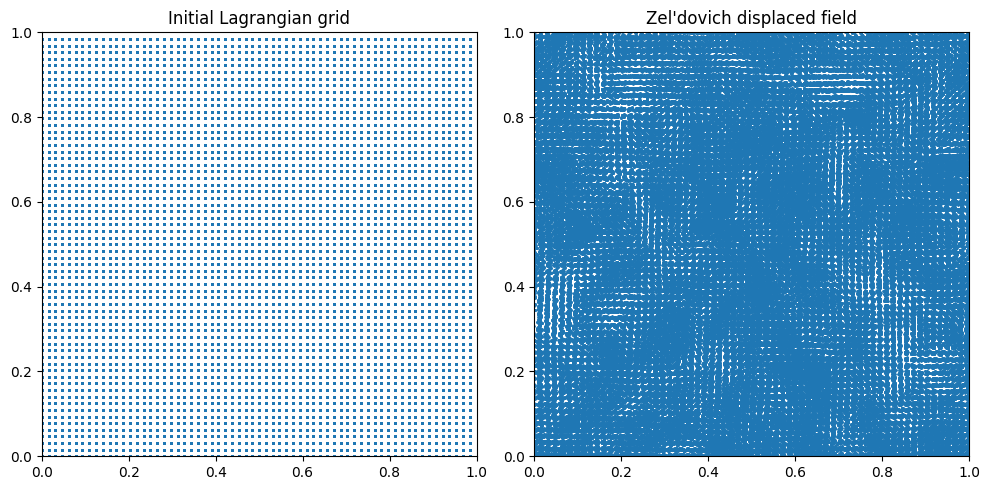

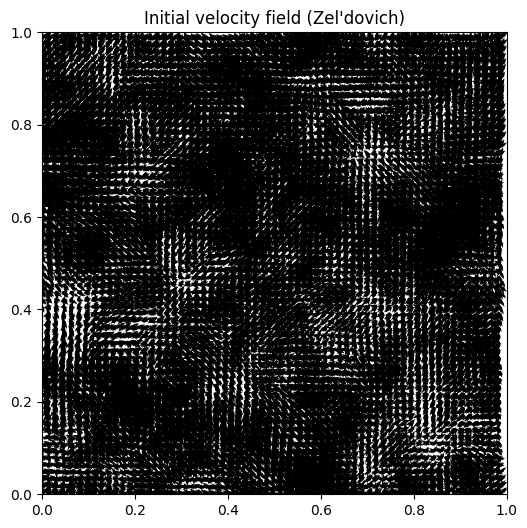

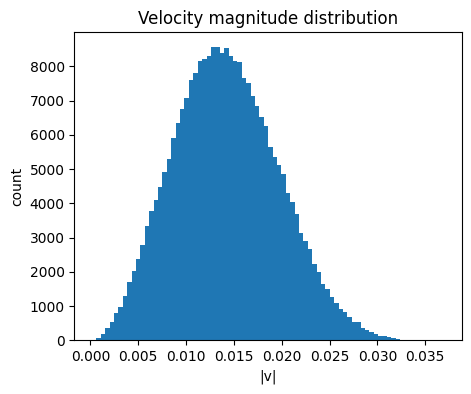

vmin: 0.0001669078002996992 vmax: 0.03699231133153896 mean: 0.014233577029075729


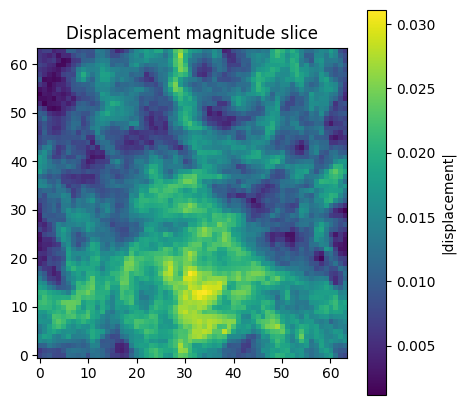

mean alignment (should be ~1): 0.9999999998272563


In [25]:
visualize_initial_conditions(pos_initial, pos_final, vel, disp, n, box_size)

STEP 3: MAIN LOOP, IMPLEMENTING GRAVITY SOLVER

In [26]:
## CIC (cloud-in-cell) density assignment (converts particles to grid density) is:
## a way to turn discrete particles into a smooth, mass-conserving density field by
## linearly weighting each particle across the 8 surrounding grid cells based on distance.
## instead of dumping a particle into one cell, we “spread its mass across the 8 surrounding grid cells proportionally to distance”
## each particle is a "cloud," and the grid cells sample how much cloud overlaps them
## each grid corner gets a weight based on distance in x, y, z.

## CIC density calculations
def cic_density(pos, n, box_size):

    rho = np.zeros((n, n, n), dtype = np.float64)
    dx = box_size / n

    ## particle's distance along the grid 
    x = pos / dx
    i = np.floor(x).astype(int)
    f = x - i

    ## periodic boundary conditions (if a particle goes far enough to the left it ends up coming back in from the right)
    i0 = i % n

    ## fraction of the grid that the particle is closest to
    fx, fy, fz = f[:, 0], f[:, 1], f[:, 2]

    ## computing weights
    wx0, wx1 = 1 - fx, fx
    wy0, wy1 = 1 - fy, fy
    wz0, wz1 = 1 - fz, fz

    ## computing weights based on which vertex the particle is closest to
    for dx_i, wx in [(0, wx0), (1, wx1)]:
        for dy_i, wy in [(0, wy0), (1, wy1)]:
            for dz_i, wz in [(0, wz0), (1, wz1)]:

                ## overall weight is simply the product of the weights in each direction
                w = wx * wy * wz

                ## updating the particle position and applying periodic boundary conditions (a way to avoid edge effects)
                ix = (i0[:, 0] + dx_i) % n
                iy = (i0[:, 1] + dy_i) % n
                iz = (i0[:, 2] + dz_i) % n

                np.add.at(rho, (ix, iy, iz), w)

    return rho / np.mean(rho)


## gravitational force solver
def compute_force(pos, n, box_size, G, kx, ky, kz, softening = 0.01):

    ## computing the density contrast
    rho = cic_density(pos, n, box_size)
    delta = rho - 1.0

    ## FFT of rho
    delta_k = np.fft.fftn(delta)

    ## computing k^2, adjusting with a small softening length
    k2 = kx**2 + ky**2 + kz**2
    ksoft2 = k2 + (softening * 2*np.pi / box_size)**2
    ksoft2[0, 0, 0] = 1.0

    ## computing the FFT of the Poisson equation for Newtonian gravity
    phi_k = -4 * np.pi * G * delta_k / ksoft2
    phi_k[0, 0, 0] = 0.0

    # Since the force = -∇φ, we can compute the force components in Fourier space
    fx_k = -1j * kx * phi_k
    fy_k = -1j * ky * phi_k
    fz_k = -1j * kz * phi_k

    ## then convert back to position-space to get our force components
    fx = np.fft.ifftn(fx_k).real
    fy = np.fft.ifftn(fy_k).real
    fz = np.fft.ifftn(fz_k).real

    return fx, fy, fz


## force interpolation
def interpolate_force(pos, fx, fy, fz, box_size):

    n = fx.shape[0]
    dx = box_size / n

    x = pos / dx
    i = np.floor(x).astype(int)
    f = x - i

    i0 = i % n

    fx_p = np.zeros(len(pos))
    fy_p = np.zeros(len(pos))
    fz_p = np.zeros(len(pos))

    wx0, wx1 = 1 - f[:, 0], f[:, 0]
    wy0, wy1 = 1 - f[:, 1], f[:, 1]
    wz0, wz1 = 1 - f[:, 2], f[:, 2]

    for dx_i, wx in [(0, wx0), (1, wx1)]:
        for dy_i, wy in [(0, wy0), (1, wy1)]:
            for dz_i, wz in [(0, wz0), (1, wz1)]:

                w = wx * wy * wz

                ix = (i0[:, 0] + dx_i) % n
                iy = (i0[:, 1] + dy_i) % n
                iz = (i0[:, 2] + dz_i) % n

                fx_p += w * fx[ix, iy, iz]
                fy_p += w * fy[ix, iy, iz]
                fz_p += w * fz[ix, iy, iz]

    return np.stack([fx_p, fy_p, fz_p], axis = 1)


## leapfrog integration
def leapfrog(pos, vel, force, dt, box_size):

    vel_half = vel + 0.5 * dt * force
    pos_new = (pos + dt * vel_half) % box_size

    return pos_new, vel_half



def make_kgrid(n, box_size):
    kfreq = np.fft.fftfreq(n, d=box_size/n) * (2*np.pi)
    return np.meshgrid(kfreq, kfreq, kfreq, indexing="ij")


## full PM step
def pm_step(pos, vel, n, box_size, dt, G, kx, ky, kz, softening=0.01):

    # force at current positions
    fx, fy, fz = compute_force(pos, n, box_size, G, kx, ky, kz, softening)
    force = interpolate_force(pos, fx, fy, fz, box_size)

    # kick + drift
    pos_new, vel_half = leapfrog(pos, vel, force, dt, box_size)

    # force at new positions
    fx2, fy2, fz2 = compute_force(pos_new, n, box_size, G, kx, ky, kz, softening)
    force_new = interpolate_force(pos_new, fx2, fy2, fz2, box_size)

    # second kick
    vel_new = vel_half + 0.5 * dt * force_new

    return pos_new, vel_new

Now that we have this pipeline, let's test it out!!

In [27]:
def run_simulation(pos, vel, n, box_size, dt, nsteps, G, kx, ky, kz, softening = 0.01):

    frames = []

    print("Simulation started...")

    for step in range(nsteps):

        t0 = time.time()

        pos, vel = pm_step(pos, vel, n, box_size, dt, G, kx, ky, kz, softening)

        print(f"step {step} done in {time.time() - t0:.3f}s")

        frames.append(pos.copy())

    print("Simulation complete!")

    return frames


def plot_particles_3d(pos, box_size):

    fig = plt.figure(figsize = (6, 6))
    ax = fig.add_subplot(111, projection = '3d')

    ax.scatter(pos[:,0], pos[:,1], pos[:,2], s = 0.25, alpha = 0.15)

    ax.set_xlim(0, box_size)
    ax.set_ylim(0, box_size)
    ax.set_zlim(0, box_size)

    plt.show()


def save_particle_frames_3d(frames, box_size, outdir = "particle_frames_3d"):
    
    os.makedirs(outdir, exist_ok = True)

    for i, pos in enumerate(frames):

        print(f"Rendering frame {i}")

        fig = plt.figure(figsize = (5,5))
        ax = fig.add_subplot(111, projection = '3d')

        ax.scatter(pos[:,0], pos[:,1], pos[:,2], s = 0.25, alpha = 0.15)

        ax.set_xlim(0, box_size)
        ax.set_ylim(0, box_size)
        ax.set_zlim(0, box_size)

        # fixed camera angle (VERY important for coherence)
        ax.view_init(elev = 20, azim = 30)

        ax.set_title(f"step {i}")

        plt.savefig(f"{outdir}/frame_{i:04d}.png", dpi = 100, bbox_inches = "tight")

        print(f"Saved frame {i}")

        plt.close(fig)


def make_gif(folder, output = "particles_3d.gif", fps = 5):

    files = sorted([
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.endswith(".png")
    ])

    images = [imageio.imread(f) for f in files]

    imageio.mimsave(output, images, fps = fps)

    print("Saved:", output)


kx, ky, kz = make_kgrid(n, box_size)
particle_frames = run_simulation(pos_final, vel, n, box_size, dt, nsteps, G, kx, ky, kz)
save_particle_frames_3d(particle_frames, box_size)
make_gif("particle_frames_3d", "particles_3d.gif", fps = 5)

Simulation started...
step 0 done in 1.546s
step 1 done in 1.525s
step 2 done in 1.470s
step 3 done in 1.420s
step 4 done in 1.442s
step 5 done in 1.463s
step 6 done in 1.432s
step 7 done in 1.456s
step 8 done in 1.411s
step 9 done in 1.449s
step 10 done in 1.475s
step 11 done in 1.457s
step 12 done in 1.424s
step 13 done in 1.472s
step 14 done in 1.447s
step 15 done in 1.452s
step 16 done in 1.466s
step 17 done in 1.470s
step 18 done in 1.435s
step 19 done in 1.448s
step 20 done in 1.439s
step 21 done in 1.459s
step 22 done in 1.488s
step 23 done in 1.493s
step 24 done in 1.477s
step 25 done in 1.436s
step 26 done in 1.463s
step 27 done in 1.475s
step 28 done in 1.446s
step 29 done in 1.457s
step 30 done in 1.461s
step 31 done in 1.464s
step 32 done in 1.597s
step 33 done in 1.434s
step 34 done in 1.344s
step 35 done in 1.489s
step 36 done in 1.461s
step 37 done in 1.448s
step 38 done in 1.477s
step 39 done in 1.499s
step 40 done in 1.467s
step 41 done in 1.469s
step 42 done in 1.468s